In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
%matplotlib inline

In [105]:
df = pd.read_csv('homeprices_banglore.csv')
df.sample(5)

,area,bedrooms,price
17,1540,3,60.00
3,1521,3,75.00
0,1056,2,39.07
16,1180,3,48.00
8,1310,3,50.00


In [106]:
from sklearn import preprocessing

sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

X = sx.fit_transform(df[['area', 'bedrooms']])
y = sy.fit_transform(df[['price']])
print(X.shape, y.shape)

(20, 2) (20, 1)


In [107]:
def batch_gradient_descent(X,y,epochs,learning_rate=0.01):
    number_of_features = X.shape[1]
    w = np.ones(shape=(number_of_features,1))
    b = 0
    n = X.shape[0]
    cost_list = []
    epoch_list = []

    for i in range(epochs):
        y_predicted = np.dot(X,w) + b
        dw = -(2/n)*np.dot(X.T,(y-y_predicted))
        db = -(2/n)*np.sum(y-y_predicted)
        w = w - learning_rate*dw
        b = b - learning_rate*db
        cost = np.mean(np.square(y-y_predicted))
        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
    return w,b, cost, cost_list, epoch_list


In [108]:
w,b, cost, cost_list, epoch_list = batch_gradient_descent(X,y,epochs=1000)
w,b,cost

(array([[0.66469087],
        [0.60541671]]),
 np.float64(-0.17792104056392882),
 np.float64(0.0048654808183488454))

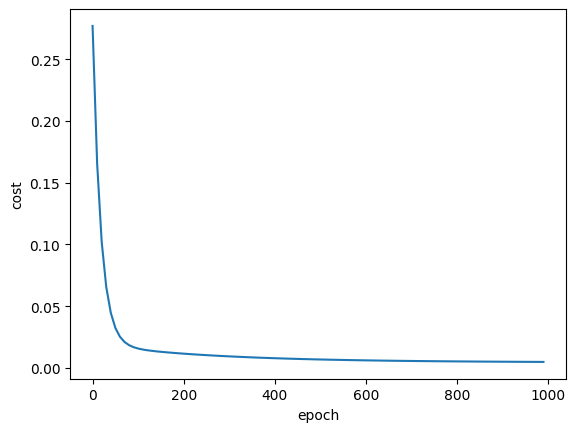

In [109]:
plt.xlabel('epoch')
plt.ylabel('cost')
plt.plot(epoch_list, cost_list)

In [110]:
def predict(area, bedrooms, w, b):
    x = sx.transform([[area, bedrooms]])
    price = np.dot(x,w) + b
    scaled_price = sy.inverse_transform(price)
    return scaled_price[0][0]


In [111]:
predict(2600, 4, w, b)

c:\Users\Sujata\Music\Deep_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(124.97561189905038)

In [112]:
def stochastic_gradient_descent(X,y,epochs,learning_rate=0.01):
    number_of_features = X.shape[1]
    w = np.ones(shape=(number_of_features,1))
    b = 0
    n = X.shape[0]
    cost_list = []
    epoch_list = []

    for i in range(epochs):
        random_index = random.randint(0,n-1)
        sample_x = X[random_index].reshape(1,X.shape[1])
        sample_y = y[random_index]
        y_predicted = np.dot(sample_x,w) + b
        dw = -2*np.dot(sample_x.T,(sample_y-y_predicted))
        db = -2*np.sum(sample_y-y_predicted)
        w = w - learning_rate*dw
        b = b - learning_rate*db
        cost = np.mean(np.square(sample_y-y_predicted))
        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
    return w,b, cost, cost_list, epoch_list

In [113]:
w_sgd,b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(X,y,epochs=1000)
w_sgd, b_sgd, cost_sgd

(array([[0.66621965],
        [0.60182411]]),
 np.float64(-0.17761232615182004),
 np.float64(0.00031969658788339416))

In [114]:
w,b,cost

(array([[0.66469087],
        [0.60541671]]),
 np.float64(-0.17792104056392882),
 np.float64(0.0048654808183488454))

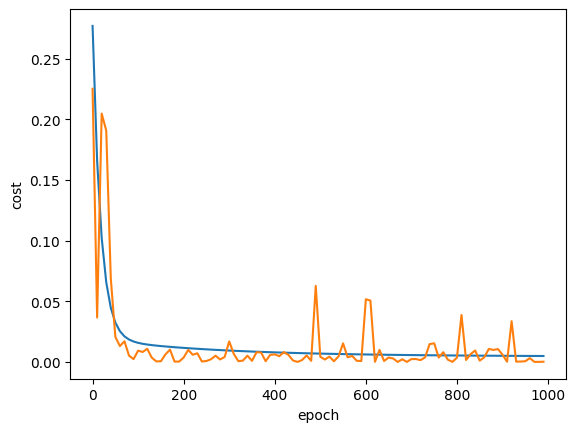

In [115]:
plt.xlabel('epoch')
plt.ylabel('cost')
plt.plot(epoch_list, cost_list)
plt.plot(epoch_list_sgd, cost_list_sgd)

In [116]:
def mini_batch_gradient_descent(X,y,epochs,learning_rate=0.01,batch_size=20):
    number_of_features = X.shape[1]
    w = np.ones(shape=(number_of_features,1))
    b = 0
    n = X.shape[0]
    cost_list = []
    epoch_list = []

    for i in range(epochs):
        random_indices = np.random.choice(n, batch_size)
        X_batch = X[random_indices]
        y_batch = y[random_indices]
        y_predicted = np.dot(X_batch,w) + b
        dw = -(2/batch_size)*np.dot(X_batch.T,(y_batch-y_predicted))
        db = -(2/batch_size)*np.sum(y_batch-y_predicted)
        w = w - learning_rate*dw
        b = b - learning_rate*db
        cost = np.mean(np.square(y_batch-y_predicted))
        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
    return w,b, cost, cost_list, epoch_list

In [117]:
w_mb,b_mb, cost_mb, cost_list_mb, epoch_list_mb = mini_batch_gradient_descent(X,y,epochs=1000)
w_mb, b_mb, cost_mb

(array([[0.66540874],
        [0.60362921]]),
 np.float64(-0.18122627404551328),
 np.float64(0.006291849383151159))

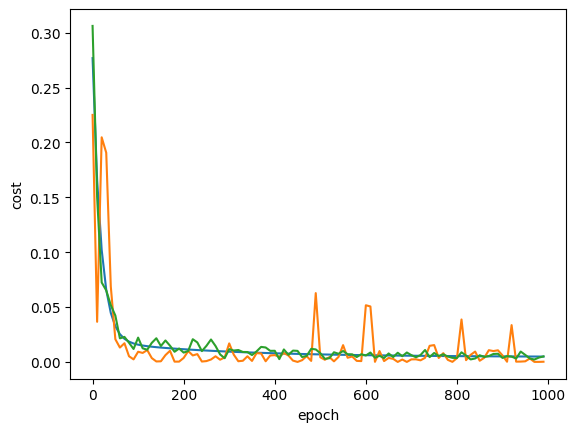

In [118]:
plt.xlabel('epoch')
plt.ylabel('cost')
plt.plot(epoch_list, cost_list)
plt.plot(epoch_list_sgd, cost_list_sgd)
plt.plot(epoch_list_mb, cost_list_mb)